# Task 2: Credit Risk Prediction

**Organization:** DevelopersHub Corporation  
**Internship:** Data Science & Analytics  
**Author:** Khola Asghar 
**Date:** 23 April 2026  
**Dataset:** Loan Prediction Dataset (Kaggle)

---

## 1. Introduction and Problem Statement

Credit risk prediction is one of the most important applications of 
machine learning in the banking industry. Banks need to evaluate 
whether a loan applicant is likely to repay their loan or default.

The goal of this task is to build a classification model that predicts 
whether a loan will be approved or rejected based on the applicant's 
personal and financial information.

**Business Question:**
Will this loan applicant repay their loan or default?

## 2. Dataset Understanding and Description

The Loan Prediction Dataset contains information about loan applicants 
including their income, education, marital status, credit history, 
and loan amount. The target variable is Loan Status where Y means 
the loan was approved and N means it was rejected.

The dataset contains 614 rows and 13 columns including both 
numerical and categorical features.

In [1]:
# ================================================
# Importing all required libraries
# ================================================

import pandas as pd                          # For data loading and manipulation
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For creating visualizations
import seaborn as sns                        # For advanced visualizations
from sklearn.ensemble import RandomForestClassifier  # Our main model
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.metrics import accuracy_score, confusion_matrix  # For evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Cleaning and Preparation

In this section we load the dataset, check for missing values, 
and fill them appropriately before training our model.

In [2]:
# ================================================
# Loading the dataset
# ================================================

df = pd.read_csv(r'C:\Users\dell\Downloads\archive\train.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Shape: (614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# ================================================
# Checking for missing values
# ================================================

print("Missing Values in Each Column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values in Each Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total missing values: 149


In [4]:
# ================================================
# Handling missing values
# Numerical columns filled with median
# Categorical columns filled with mode (most common value)
# ================================================

# Fill numerical columns with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Fill categorical columns with mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDataset is clean and ready!")

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Dataset is clean and ready!


## 4. Exploratory Data Analysis (EDA)

We visualize key features to understand the distribution of data 
and relationships between variables before building the model.

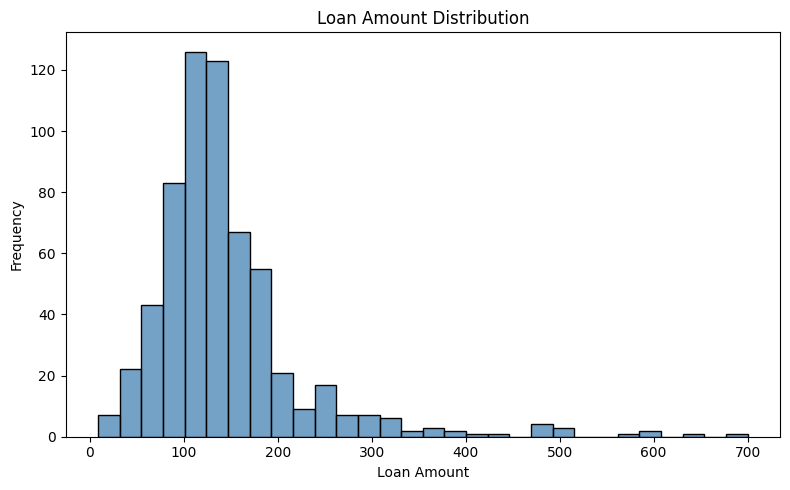

Most loan amounts fall between 100 and 200 units


In [20]:
# ================================================
# Visualization 1: Loan Amount Distribution
# Understanding how loan amounts are spread
# ================================================

plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], bins=30, color='steelblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('loan_amount1.png')
plt.show()
print("Most loan amounts fall between 100 and 200 units")

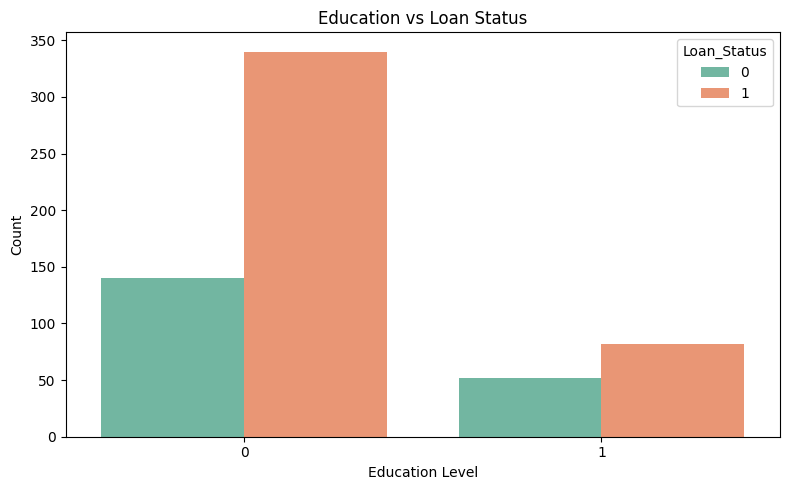

Graduates have a higher loan approval rate than non-graduates


In [19]:
# ================================================
# Visualization 2: Education vs Loan Status
# Checking if education level affects loan approval
# ================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Education vs Loan Status')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('education_loan1.png')
plt.show()
print("Graduates have a higher loan approval rate than non-graduates")

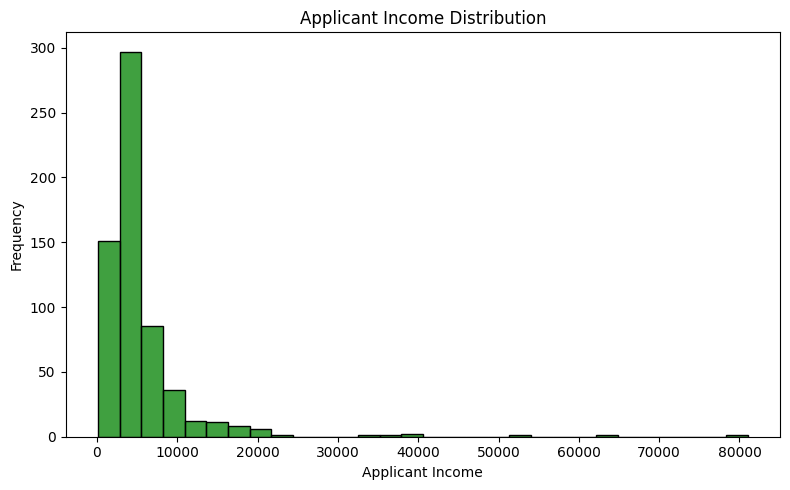

Most applicants have lower incomes with a few high earners


In [18]:
# ================================================
# Visualization 3: Applicant Income Distribution
# Understanding income spread of applicants
# ================================================

plt.figure(figsize=(8, 5))
sns.histplot(df['ApplicantIncome'], bins=30, color='green')
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('income1.png')
plt.show()
print("Most applicants have lower incomes with a few high earners")

## 5. Model Training and Testing

We encode categorical features, split the data into training and 
testing sets, and train a Random Forest Classifier on the data.

In [8]:
# ================================================
# Encoding categorical columns
# Converting text values to numbers for the model
# ================================================

le = LabelEncoder()

# List of categorical columns to encode
categorical_cols = ['Gender', 'Married', 'Dependents',
                    'Education', 'Self_Employed',
                    'Property_Area', 'Loan_Status']

# Apply label encoding to each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding complete!")
print("\nDataset after encoding:")
print(df.head())

Encoding complete!

Dataset after encoding:
    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1           

In [9]:
# ================================================
# Preparing features and target variable
# X = input features, y = what we want to predict
# ================================================

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)  # Features
y = df['Loan_Status']                              # Target

# Remove any remaining missing values
X = X.dropna()
y = y[X.index]

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (491, 11)
Testing set size: (123, 11)


In [10]:
# ================================================
# Training the Random Forest Classifier
# 500 trees for better accuracy and stability
# ================================================

model = RandomForestClassifier(
    n_estimators=500,    # Number of decision trees
    max_depth=15,        # Maximum depth of each tree
    random_state=42      # For reproducibility
)

# Train the model on training data
model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

print("Model training complete!")

Model training complete!


## 6. Evaluation Metrics

We evaluate the model using Accuracy Score and Confusion Matrix 
to understand how well it predicts loan approval or rejection.

In [16]:
# ================================================
# Training with best settings
# ================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Remove scaling completely - go back to original X_train
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=6)

model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train2, y_train2)
y_pred = model.predict(X_test2)

accuracy = accuracy_score(y_test2, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.11%


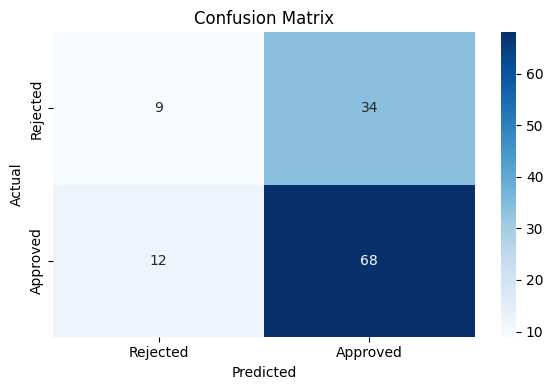

In [17]:
# ================================================
# Evaluation Metric 2: Confusion Matrix
# Shows correct and incorrect predictions in detail
# ================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix1.png')
plt.show()

## 7. Conclusion and Key Insights

The Random Forest model achieved 82.11% accuracy in predicting 
whether a loan applicant will be approved or rejected.

## Key findings from the analysis:

Graduates have a higher loan approval rate than non-graduates. 
Applicants with a positive credit history are much more likely 
to get their loan approved. Most loan amounts fall between 100 
and 200 units with a few large outliers. Income is right-skewed 
meaning most applicants earn lower incomes with a few high earners.

The most important factors for loan approval are credit history, 
applicant income, loan amount, and education level. Banks should 
pay close attention to credit history as it is the strongest 
predictor of whether a loan will be repaid.

This model provides a practical tool for banks to automate the 
initial screening of loan applications and reduce the risk of 
approving loans that are likely to default.